# Dự án: Classifying Spam Emails - End-to-End Machine Learning Pipeline

Notebook này là bản tổng hợp cuối cùng cho project phân loại email spam/not spam. Nội dung được sắp xếp theo mạch báo cáo: phân tích bài toán, mô tả dữ liệu, EDA, preprocessing, feature engineering, huấn luyện, đánh giá, chọn mô hình và hướng triển khai.

> Ghi chú: Notebook này ưu tiên đọc các artifact đã sinh trong `reports/` và `reports/figures/`, không train lại model từ đầu. Vì vậy `Run All` sẽ chạy nhanh và ổn định hơn.


## 1. Phân tích bài toán

Đề bài yêu cầu xây dựng hệ thống phân loại email thành hai lớp:

| Nhãn | Ý nghĩa |
|---:|---|
| `0` | Not spam / ham |
| `1` | Spam |

Đây là bài toán **binary classification có giám sát**. Mỗi email trong tập train có nội dung văn bản và nhãn thật. Mô hình học từ các email đã gán nhãn để dự đoán email mới là spam hay không spam.

**Input:** subject/body email dạng text, có thể kèm metadata nếu dataset cung cấp.  
**Output:** nhãn dự đoán `spam` hoặc `not spam`.  
**Mô hình so sánh:** Naive Bayes, Logistic Regression, Linear SVM.  
**Metric chính:** Precision, Recall và F1-score cho lớp spam.

Accuracy không nên là tiêu chí duy nhất vì nếu dữ liệu lệch lớp, model có thể accuracy cao nhưng vẫn bỏ sót nhiều email spam.


## 2. Thiết lập và nạp artifact

Cell dưới chỉ nạp các file báo cáo, metric và hình ảnh đã có. Nó không đọc lại dataset lớn và không train model.


In [1]:
from pathlib import Path
import json
import sys
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
SAMPLE_EMAILS_DIR = PROJECT_ROOT / "sample_emails"

def read_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    return json.loads(path.read_text(encoding="utf-8", errors="replace"))

def read_csv_if_exists(path):
    path = Path(path)
    return pd.read_csv(path) if path.exists() else pd.DataFrame()

loader_report = read_json(REPORTS_DIR / "data_loader_report.json")
quality_report = read_json(REPORTS_DIR / "data_quality_report.json")
train_report = read_json(REPORTS_DIR / "model_train_report.json")
metrics_df = read_csv_if_exists(REPORTS_DIR / "model_metrics.csv")
comparison_df = read_csv_if_exists(FIGURES_DIR / "model_comparison.csv")
if comparison_df.empty and not metrics_df.empty:
    comparison_df = metrics_df.copy()

print("Project root:", PROJECT_ROOT)
print("Reports available:", REPORTS_DIR.exists())
print("Figures available:", FIGURES_DIR.exists())

Project root: c:\Users\ADMIN\Desktop\lab1_updated\Project-Classifying-Spam-Emails-main
Reports available: True
Figures available: True


## 3. Dữ liệu

Project gộp dữ liệu từ các corpus email public. Với dataset `locuoco`, các nhãn `spam` và `phish` được quy về nhãn nhị phân `1 = spam` để phù hợp đề bài.


In [2]:
summary_rows = []
for name in ["spamassassin_labeled", "spamassassin_balanced", "combined_labeled", "combined_balanced"]:
    item = loader_report.get(name, {})
    if item:
        counts = item.get("label_counts", {})
        summary_rows.append({
            "dataset": name,
            "rows": item.get("row_count"),
            "not_spam_0": counts.get("0", counts.get(0)),
            "spam_1": counts.get("1", counts.get(1)),
            "short_text": item.get("short_text_count"),
            "duplicates": item.get("duplicate_text_count"),
            "valid": item.get("is_valid"),
        })

dataset_summary = pd.DataFrame(summary_rows)
display(dataset_summary)

source_counts = loader_report.get("source_counts", {})
if source_counts:
    source_df = pd.DataFrame(source_counts.items(), columns=["source", "rows"]).sort_values("rows", ascending=False)
    display(source_df)

,dataset,rows,not_spam_0,spam_1,short_text,duplicates,valid
0,spamassassin_labeled,5903,4112,1791,3,0,True
1,spamassassin_balanced,3582,1791,1791,3,0,True
2,combined_labeled,315668,148098,167570,1252,10,True
3,combined_balanced,296196,148098,148098,1156,10,True


,source,rows
0,locuoco_big_spam_ham_phish_300k,279304
1,setfit_enron_spam,30461
2,easy_ham,2472
3,easy_ham_2,1389
4,spam_2,1315
5,spam,476
6,hard_ham,251


### Số lượng spam và not spam sau khi làm sạch

Con số nên ghi trong báo cáo là tập clean sau khi lọc dữ liệu lỗi/quá ngắn.


In [3]:
clean_counts = quality_report.get("clean_label_counts", {})
spam_count = clean_counts.get("1", clean_counts.get(1))
not_spam_count = clean_counts.get("0", clean_counts.get(0))

clean_label_df = pd.DataFrame([
    {"label": "not spam (0)", "count": not_spam_count},
    {"label": "spam (1)", "count": spam_count},
])
display(clean_label_df)
print(f"Clean dataset total: {quality_report.get('clean_rows')} rows")

,label,count
0,not spam (0),147359
1,spam (1),147359


Clean dataset total: 294718 rows


## 4. Data Quality

Pipeline kiểm tra các lỗi chính trước khi huấn luyện: nhãn không hợp lệ, email rỗng/quá ngắn, dòng trùng lặp và thiếu cột bắt buộc.


In [4]:
quality_display = {
    "input_rows": quality_report.get("input_rows"),
    "clean_rows": quality_report.get("clean_rows"),
    "removed_rows": quality_report.get("removed_rows"),
    "input_label_counts": quality_report.get("input_label_counts"),
    "clean_label_counts": quality_report.get("clean_label_counts"),
    "issue_counts": quality_report.get("issue_counts"),
    "required_columns_present": quality_report.get("required_columns_present"),
}
print(json.dumps(quality_display, indent=2, ensure_ascii=False))

issues_path = REPORTS_DIR / "data_quality_issues.csv"
if issues_path.exists():
    issues = pd.read_csv(issues_path)
    display(issues.head(10))

{
  "input_rows": 296196,
  "clean_rows": 294718,
  "removed_rows": 1478,
  "input_label_counts": {
    "0": 148098,
    "1": 148098
  },
  "clean_label_counts": {
    "0": 147359,
    "1": 147359
  },
  "issue_counts": {
    "short_text": 1156
  },
  "required_columns_present": true
}


,issue,row_index,source,file_name,label,label_name,text
0,short_text,50,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,"phelim ,\nfyi\nvince"
1,short_text,453,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,kevin kindall
2,short_text,497,locuoco_big_spam_ham_phish_300k,0001.parquet,0,ham,look
3,short_text,521,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,buenos noches g'bye
4,short_text,587,locuoco_big_spam_ham_phish_300k,0001.parquet,0,ham,go new york tonight
5,short_text,1002,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,hi try nothing
6,short_text,1418,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,basvsehp jy e snd
7,short_text,1434,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,dont like beth
8,short_text,1482,locuoco_big_spam_ham_phish_300k,0000.parquet,1,spam,maxine
9,short_text,1563,locuoco_big_spam_ham_phish_300k,0000.parquet,0,ham,hurricane elana


## 5. EDA - Phân tích khám phá dữ liệu

EDA tập trung vào phân phối nhãn, độ dài email và các feature thủ công có liên quan đến spam.


Label distribution


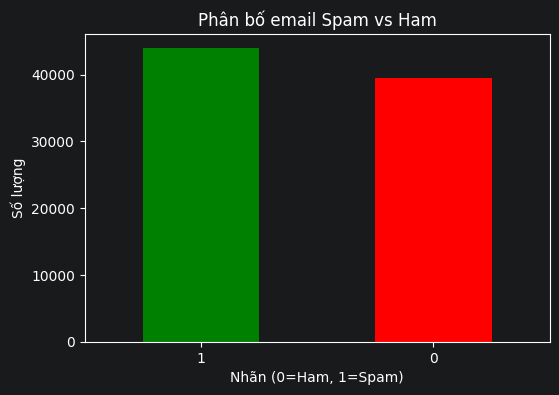

Email length distribution


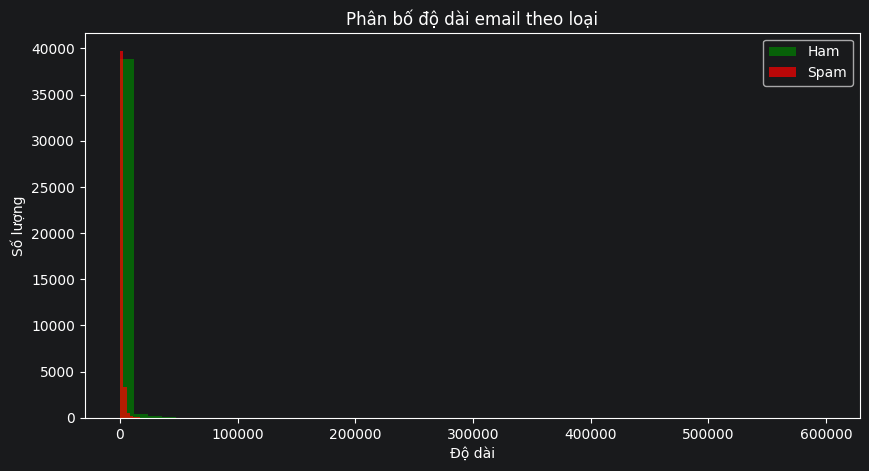

In [5]:
for title, image_name in [
    ("Label distribution", "eda_label_distribution.png"),
    ("Email length distribution", "eda_email_length_distribution.png"),
]:
    image_path = FIGURES_DIR / image_name
    print(title)
    if image_path.exists():
        display(Image(filename=str(image_path)))
    else:
        print("Missing image:", image_path)

### 5.1 Correlation heatmap của manual features

Heatmap kiểm tra tương quan Pearson giữa các feature thủ công và nhãn spam/not spam. Đây là phân tích EDA, không phải kết luận nhân quả.


,length,url_count,exclamation_count,dollar_count,uppercase_ratio,label
length,1.000000,0.005639,0.267543,0.211086,-0.026882,0.043345
url_count,0.005639,1.000000,-0.004051,-0.002959,-0.009811,-0.012143
exclamation_count,0.267543,-0.004051,1.000000,0.394232,0.167105,0.375424
dollar_count,0.211086,-0.002959,0.394232,1.000000,0.053222,0.157599
uppercase_ratio,-0.026882,-0.009811,0.167105,0.053222,1.000000,0.333270
label,0.043345,-0.012143,0.375424,0.157599,0.333270,1.000000


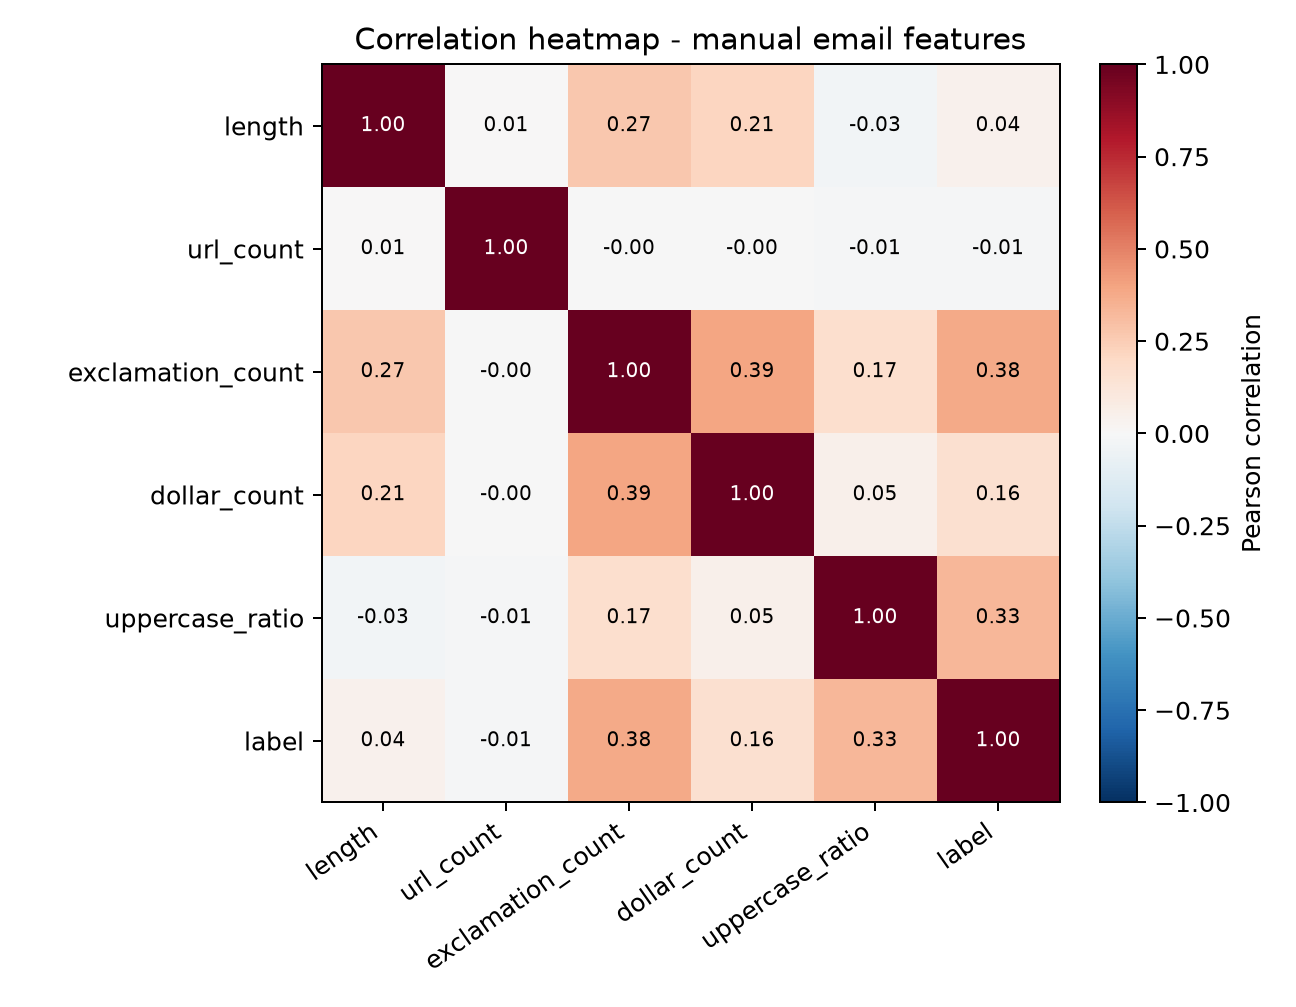

In [6]:
correlation_matrix_path = FIGURES_DIR / "manual_feature_correlation_matrix.csv"
correlation_heatmap_path = FIGURES_DIR / "manual_feature_correlation_heatmap.png"

if correlation_matrix_path.exists():
    display(pd.read_csv(correlation_matrix_path, index_col=0))

if correlation_heatmap_path.exists():
    display(Image(filename=str(correlation_heatmap_path)))
else:
    print("Missing image:", correlation_heatmap_path)

## 6. Text Preprocessing

Các bước làm sạch text gồm: xóa HTML/script/style, decode HTML entities, chuẩn hóa URL/email thành token, chuẩn hóa khoảng trắng và lowercase trong pipeline TF-IDF.


In [7]:
from src.text_preprocess import clean_email_text

examples = [
    "<html>FREE prize!!! Click https://spam.example now, contact test@example.com for 100 dollars</html>",
    "Hi team, please confirm tomorrow meeting agenda and project notes.",
]

for raw_text in examples:
    print("RAW:  ", raw_text)
    print("CLEAN:", clean_email_text(raw_text))
    print()

RAW:   <html>FREE prize!!! Click https://spam.example now, contact test@example.com for 100 dollars</html>
CLEAN: free prize click urltoken contact emailtoken numbertoken dollars

RAW:   Hi team, please confirm tomorrow meeting agenda and project notes.
CLEAN: hi team please confirm tomorrow meeting agenda project notes



## 7. Feature Engineering

Feature chính của model là TF-IDF unigram/bigram. Ngoài ra, notebook phân tích thêm các feature thủ công bám sát đề bài: `length`, `url_count`, `exclamation_count`, `dollar_count`, `uppercase_ratio`.


In [8]:
feature_summary = pd.DataFrame([
    {"feature_group": "TF-IDF unigram/bigram", "purpose": "Represent email content as sparse numeric vectors", "note": "Training pipeline uses max_features=25000 and ngram_range=(1, 2)."},
    {"feature_group": "length", "purpose": "Email length", "note": "Spam can be very short or packed with promotional content."},
    {"feature_group": "url_count", "purpose": "Number of URLs", "note": "Spam/phishing often pushes users to click links."},
    {"feature_group": "exclamation_count", "purpose": "Number of ! characters", "note": "Captures urgent promotional writing style."},
    {"feature_group": "dollar_count", "purpose": "Number of $ characters", "note": "Signals money, discounts or payment content."},
    {"feature_group": "uppercase_ratio", "purpose": "Uppercase character ratio", "note": "Spam often uses uppercase text for attention."},
])
display(feature_summary)

,feature_group,purpose,note
0,TF-IDF unigram/bigram,Represent email content as sparse numeric vectors,Training pipeline uses max_features=25000 and ...
1,length,Email length,Spam can be very short or packed with promotio...
2,url_count,Number of URLs,Spam/phishing often pushes users to click links.
3,exclamation_count,Number of ! characters,Captures urgent promotional writing style.
4,dollar_count,Number of $ characters,"Signals money, discounts or payment content."
5,uppercase_ratio,Uppercase character ratio,Spam often uses uppercase text for attention.


### 7.1 Permutation importance của manual features

Permutation importance đo mức giảm F1 khi xáo trộn từng feature. Trong mẫu SpamAssassin, `exclamation_count` và `uppercase_ratio` là hai feature thủ công nổi bật nhất.


,feature,importance_mean,importance_std
0,exclamation_count,0.216456,0.015742
1,uppercase_ratio,0.079546,0.009504
2,dollar_count,0.019217,0.004371
3,length,0.004533,0.002360
4,url_count,-0.000116,0.000275


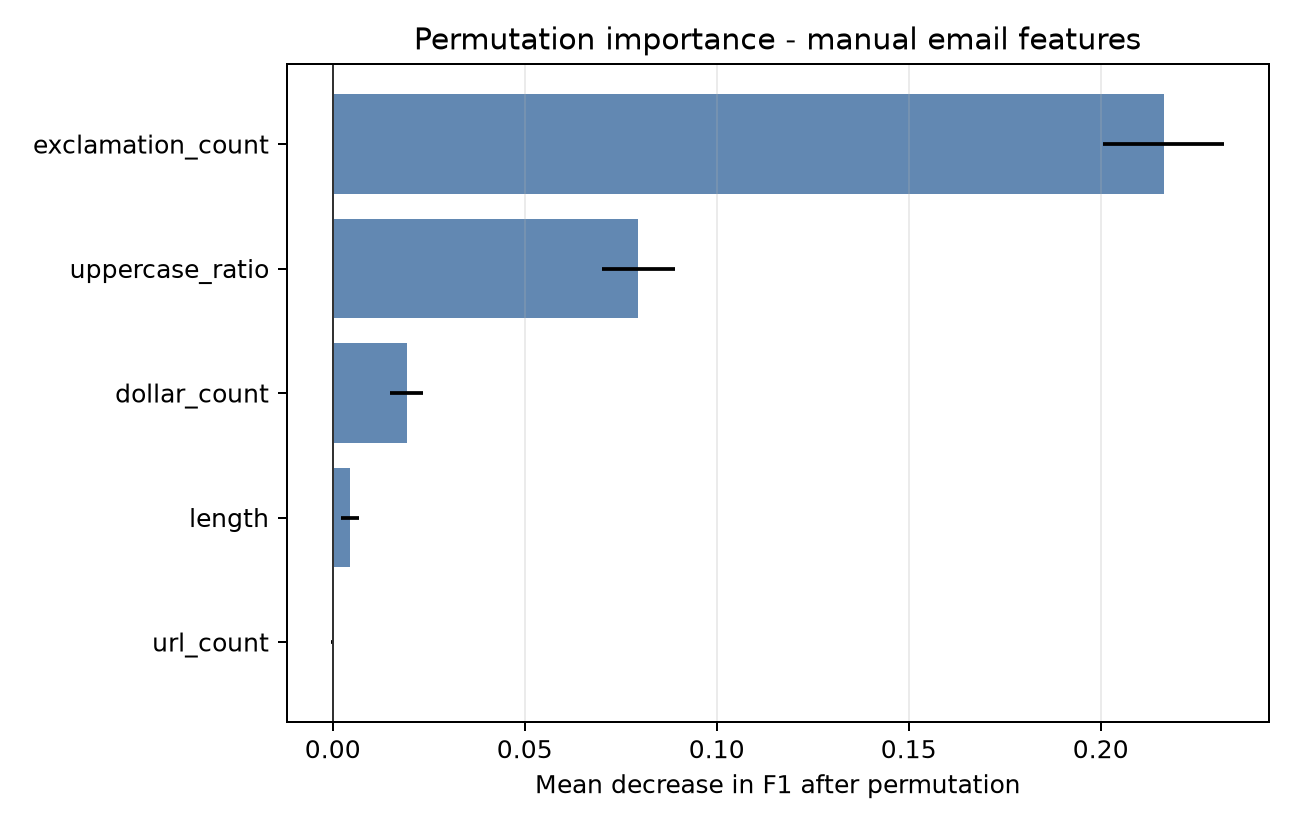

In [9]:
importance_path = FIGURES_DIR / "manual_feature_permutation_importance.csv"
importance_image_path = FIGURES_DIR / "manual_feature_permutation_importance.png"

if importance_path.exists():
    display(pd.read_csv(importance_path))

if importance_image_path.exists():
    display(Image(filename=str(importance_image_path)))
else:
    print("Missing image:", importance_image_path)

## 8. Huấn luyện model

Ba mô hình được so sánh trên cùng pipeline TF-IDF: Naive Bayes, Logistic Regression và Linear SVM. Report hiện tại dùng 60,000 mẫu, chia 48,000 train và 12,000 test.


In [10]:
print(json.dumps(train_report, indent=2, ensure_ascii=False))

{
  "best_model": "linear_svm",
  "train_rows": 48000,
  "test_rows": 12000,
  "metrics_path": "C:\\Users\\User\\OneDrive - ut.edu.vn\\Documents\\Machine Learning - Trường\\Project-Classifying-Spam-Emails\\reports\\model_metrics.csv",
  "predictions_path": "C:\\Users\\User\\OneDrive - ut.edu.vn\\Documents\\Machine Learning - Trường\\Project-Classifying-Spam-Emails\\reports\\model_predictions.csv"
}


## 9. Đánh giá model

Với spam detection, hai lỗi có tác động khác nhau:

| Lỗi | Ý nghĩa | Tác động |
|---|---|---|
| False Positive | Email tốt bị chặn nhầm | Có thể mất email quan trọng |
| False Negative | Spam lọt qua bộ lọc | Người dùng vẫn gặp rủi ro |

Do đó, notebook ưu tiên `precision_spam`, `recall_spam` và `f1_spam`.


In [11]:
if not comparison_df.empty:
    sort_cols = [col for col in ["f1_spam", "recall_spam", "precision_spam"] if col in comparison_df.columns]
    comparison_sorted = comparison_df.sort_values(sort_cols, ascending=False).reset_index(drop=True)
    display(comparison_sorted)

    best_row = comparison_sorted.iloc[0]
    print("Best model:", best_row["model"])
    print("Accuracy:", round(best_row["accuracy"], 4))
    print("Precision spam:", round(best_row["precision_spam"], 4))
    print("Recall spam:", round(best_row["recall_spam"], 4))
    print("F1 spam:", round(best_row["f1_spam"], 4))
    if "false_positive_rate" in best_row:
        print("False positive rate:", round(best_row["false_positive_rate"], 4))
else:
    print("No comparison table found.")

,model,accuracy,precision_spam,recall_spam,f1_spam,false_positive_rate,tn,fp,fn,tp,total,confusion_matrix_path
0,linear_svm,0.979167,0.979007,0.979333,0.979170,0.021000,5874,126,124,5876,12000,C:\Users\ADMIN\Desktop\lab1_updated\Project-Cl...
1,logistic_regression,0.974000,0.970394,0.977833,0.974099,0.029833,5821,179,133,5867,12000,C:\Users\ADMIN\Desktop\lab1_updated\Project-Cl...
2,naive_bayes,0.963417,0.977339,0.948833,0.962875,0.022000,5868,132,307,5693,12000,C:\Users\ADMIN\Desktop\lab1_updated\Project-Cl...


Best model: linear_svm
Accuracy: 0.9792
Precision spam: 0.979
Recall spam: 0.9793
F1 spam: 0.9792
False positive rate: 0.021


Model metric comparison


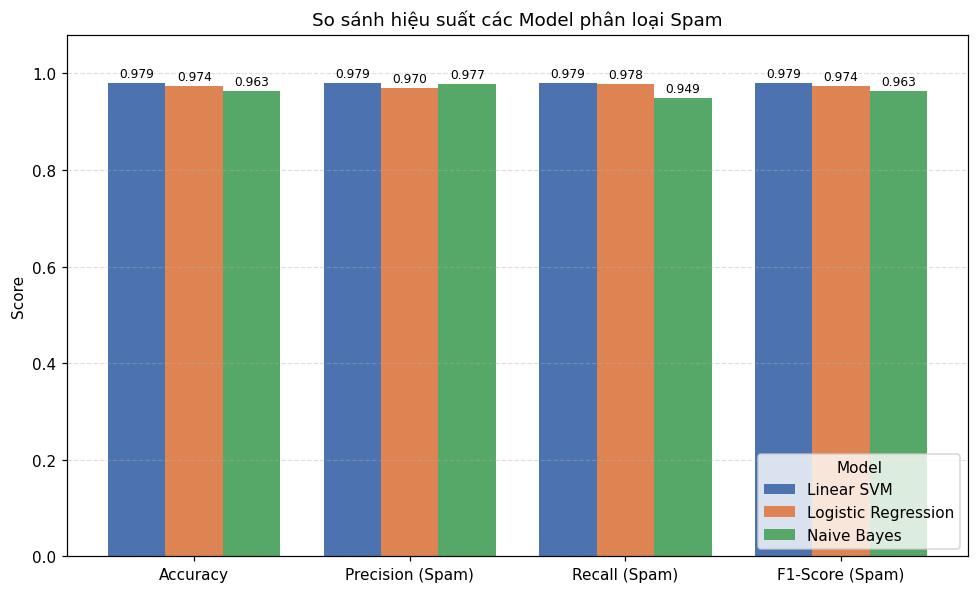

Confusion matrix grid


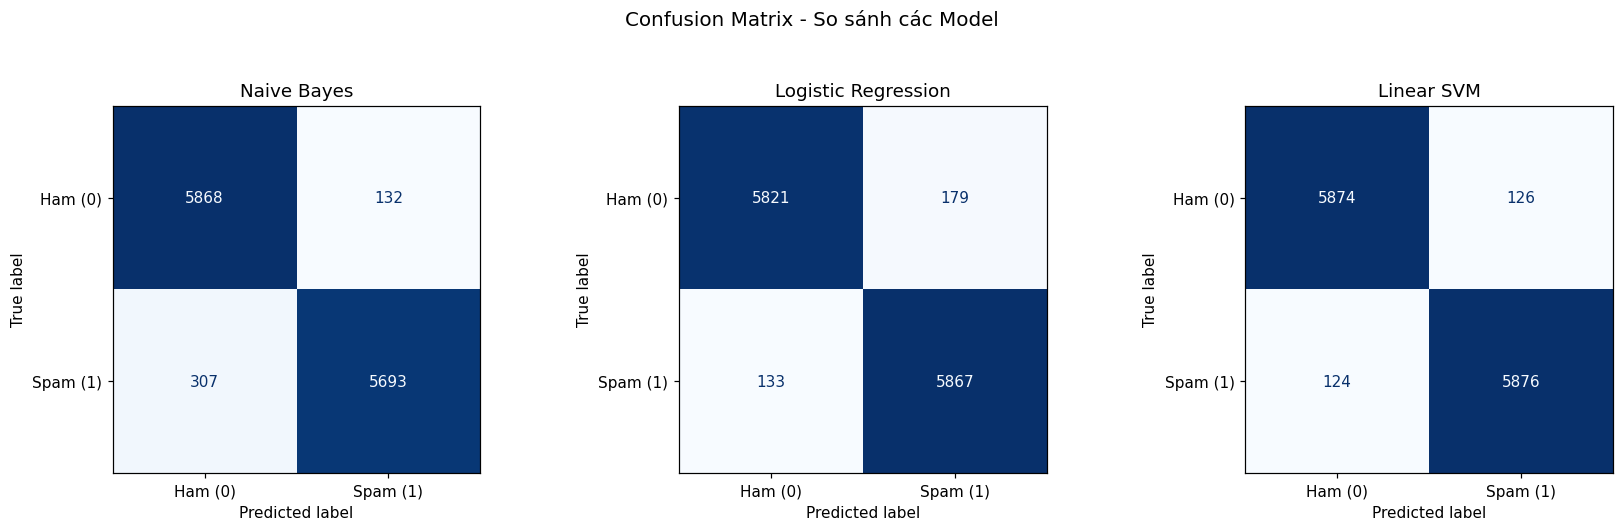

In [12]:
metrics_bar_path = FIGURES_DIR / "model_metrics_bar_chart.png"
confusion_grid_path = FIGURES_DIR / "model_confusion_matrix_grid.png"

for title, image_path in [
    ("Model metric comparison", metrics_bar_path),
    ("Confusion matrix grid", confusion_grid_path),
]:
    print(title)
    if image_path.exists():
        display(Image(filename=str(image_path)))
    else:
        print("Missing image:", image_path)

## 10. Chọn mô hình cuối

Model cuối được chọn là **TF-IDF + Linear SVM** vì F1 spam cao nhất, accuracy cao nhất và precision/recall spam cân bằng. Linear SVM cũng là lựa chọn phù hợp cho dữ liệu text sparse/high-dimensional từ TF-IDF.


## 11. Demo và triển khai

Project có module `src/predict.py` và giao diện Flask trong `app.py`. Trong notebook tổng, demo được trình bày dạng bảng nhẹ để `Run All` không phải load lại model `.joblib`.


In [13]:
demo_results = pd.DataFrame([
    {
        "email_example": "Congratulations winner, claim your free lottery prize money now!!!",
        "expected_prediction": "spam",
        "reason": "Contains prize/claim/free and urgent promotional wording.",
    },
    {
        "email_example": "Hi team, please review the meeting notes and send feedback by Friday.",
        "expected_prediction": "not spam",
        "reason": "Normal work context, no spam-like urgency or money/prize cue.",
    },
])
display(demo_results)

if SAMPLE_EMAILS_DIR.exists():
    print("Sample email files:")
    for sample_path in sorted(SAMPLE_EMAILS_DIR.glob("*.txt")):
        print("-", sample_path.name)

,email_example,expected_prediction,reason
0,"Congratulations winner, claim your free lotter...",spam,Contains prize/claim/free and urgent promotion...
1,"Hi team, please review the meeting notes and s...",not spam,"Normal work context, no spam-like urgency or m..."


Sample email files:
- borderline_01_marketing_newsletter.txt
- borderline_02_many_recipients_but_legit.txt
- notspam_01_team_meeting.txt
- notspam_02_assignment_update.txt
- notspam_03_class_reminder.txt
- notspam_04_invoice_normal.txt
- spam_01_prize_claim.txt
- spam_02_account_warning.txt
- spam_03_discount_offer.txt
- spam_04_payment_request.txt


## 12. Hạn chế và hướng phát triển

| Vấn đề | Rủi ro | Hướng xử lý |
|---|---|---|
| Dữ liệu trong zip dùng Git LFS pointer | Không retrain full dataset nếu thiếu LFS objects | Gửi kèm dữ liệu thật hoặc script tải dữ liệu |
| Spam thay đổi theo thời gian | Model có thể giảm hiệu quả | Cập nhật dữ liệu định kỳ |
| Linear SVM không có xác suất tự nhiên | `spam_score` cần calibration nếu dùng threshold | Dùng `CalibratedClassifierCV` |
| False positive vẫn tồn tại | Email tốt có thể bị chặn nhầm | Tối ưu threshold, whitelist, review feedback |


## 13. Kết luận

Project đã xây dựng được pipeline phân loại spam email hoàn chỉnh: thu thập/gộp dữ liệu, cân bằng lớp, kiểm tra chất lượng, tiền xử lý text, vector hóa TF-IDF, huấn luyện nhiều model và chọn model cuối dựa trên metric phù hợp.

Theo report hiện có, **Linear SVM** là model tốt nhất với **F1 spam = 0.9792**, **precision spam = 0.9790**, **recall spam = 0.9793**. Tập clean sau lọc có **147,359 not spam** và **147,359 spam**.
